# Tutorial 10: Image Segmentation using U-Net (Custom Model)

### Step 1: Importing Libraries and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import json

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BASE_PATH = r'C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\Tutorial10Img'
IMAGE_DIR = os.path.join(BASE_PATH, 'images')
MASK_DIR = os.path.join(BASE_PATH, 'masks')
JSON_PATH = os.path.join(BASE_PATH, 'annotations.json')

Using device: cpu


### Step 2: COCO JSON to PNG Mask Converter

In [20]:
if not os.path.exists(MASK_DIR):
    os.makedirs(MASK_DIR)

# Load the COCO JSON file you exported
with open(JSON_PATH) as f:
    data = json.load(f)

for img_info in data['images']:
    # Create a blank black mask based on original image size
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    
    img_id = img_info['id']
    annotations = [ann for ann in data['annotations'] if ann['image_id'] == img_id]
    
    for ann in annotations:
        for seg in ann['segmentation']:
            # Reshape coordinate list into (N, 2) array for OpenCV
            poly = np.array(seg).reshape((len(seg) // 2, 2)).astype(np.int32)
            cv2.fillPoly(mask, [poly], 255) # Fill silhouette with white
    
    # Save as PNG
    mask_name = img_info['file_name'].replace('.JPG', '.png')
    cv2.imwrite(os.path.join(MASK_DIR, mask_name), mask)

print(f"Done! Created {len(data['images'])} masks in {MASK_DIR}.")

Done! Created 10 masks in C:\Users\M.T\Desktop\NUST\2nd Sem\DL\DLTutorials\Tutorial10Img\masks.


### Step 3: Custom Dataset Class

In [25]:
class SprigatitoDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=128):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        # Get list of .JPG files
        self.images = [f for f in os.listdir(img_dir) if f.upper().endswith('.JPG')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        
        # Load and resize Image (RGB)
        image = cv2.imread(os.path.join(self.img_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        # Load and resize Mask (Grayscale)
        mask_name = img_name.replace(".JPG", ".png").replace(".jpg", ".png")
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        
        # Preprocessing: Normalize and change to (Channels, Height, Width)
        image_tensor = torch.tensor(image / 255.0, dtype=torch.float32).permute(2, 0, 1)
        mask_tensor = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0) 

        return image_tensor, mask_tensor

# Initialize the data loader
full_dataset = SprigatitoDataset(IMAGE_DIR, MASK_DIR)
# Using a small batch size since we only have 10 images
loader = DataLoader(full_dataset, batch_size=2, shuffle=True)

### Step 4: Modified U-Net Architecture (Task: Change the Layers)

In [26]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c), # Added layer
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c), # Added layer
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(128, 256)

        # Decoder
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128) # 128 (upsampled) + 128 (skip connection)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64) # 64 (upsampled) + 64 (skip connection)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        c1 = self.enc1(x)
        p1 = self.pool(c1)
        c2 = self.enc2(p1)
        p2 = self.pool(c2)
        b = self.bottleneck(p2)
        
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, c2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, c1], dim=1))
        
        return torch.sigmoid(self.final(d1))

model = UNet().to(device)

### Step 5: Training Loop (Task: Different Learning Rates)

--- Training with Learning Rate: 0.01 ---
Epoch [10/50], Loss: 0.1622
Epoch [20/50], Loss: 0.0661
Epoch [30/50], Loss: 0.0381
Epoch [40/50], Loss: 0.0205
Epoch [50/50], Loss: 0.1411
--- Training with Learning Rate: 0.001 ---
Epoch [10/50], Loss: 0.1175
Epoch [20/50], Loss: 0.0528
Epoch [30/50], Loss: 0.0336
Epoch [40/50], Loss: 0.0325
Epoch [50/50], Loss: 0.0271
--- Training with Learning Rate: 0.0001 ---
Epoch [10/50], Loss: 0.3152
Epoch [20/50], Loss: 0.2672
Epoch [30/50], Loss: 0.2350
Epoch [40/50], Loss: 0.2084
Epoch [50/50], Loss: 0.1890


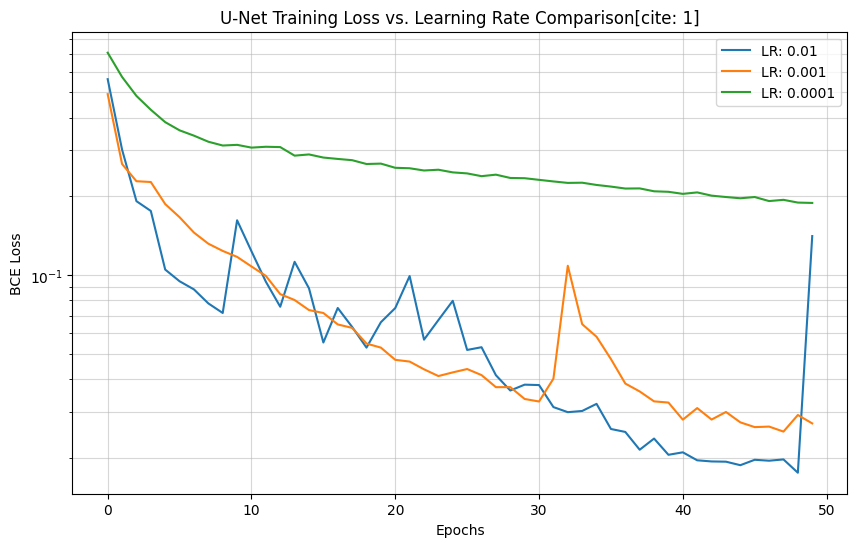

In [ ]:
# List of learning rates to test as per Tutorial 10 tasks
learning_rates = [1e-2, 1e-3, 1e-4]
all_histories = {}
trained_models = {}

# Set epochs - for 10 images, we need a few more iterations to see convergence
epochs = 50 

for lr in learning_rates:
    print(f"--- Training with Learning Rate: {lr} ---")
    
    # Re-initialize the model, optimizer, and loss for a clean test
    model = ModifiedUNet().to(device)
    criterion = nn.BCELoss() # Binary Cross Entropy for 0/1 segmentation
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for imgs, msks in loader:
            imgs, msks = imgs.to(device), msks.to(device)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, msks)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
            
    all_histories[lr] = history
    trained_models[lr] = model

# Plotting the results to compare convergence
plt.figure(figsize=(10, 6))
for lr, history in all_histories.items():
    plt.plot(history, label=f"LR: {lr}")

plt.title("U-Net Training Loss vs. Learning Rate Comparison")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.yscale('log') # Log scale helps visualize small differences in loss
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### Step 5: Visualize Predictions (Task: Visualizing Results)

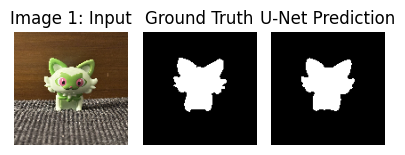

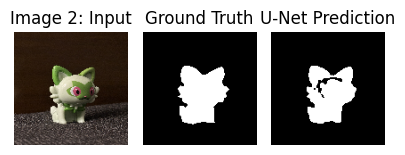

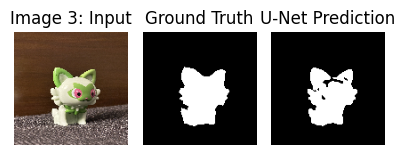

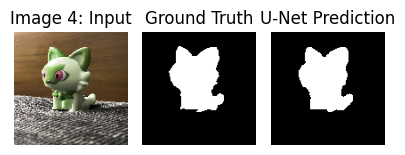

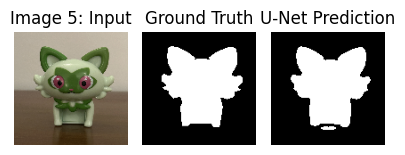

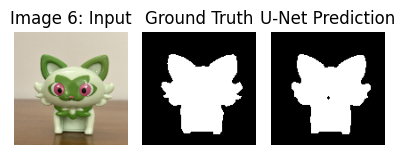

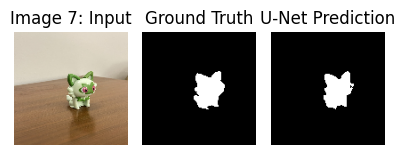

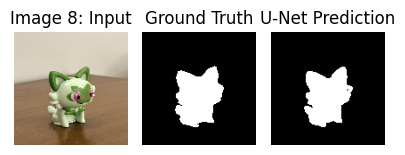

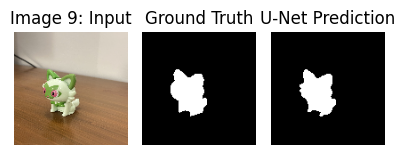

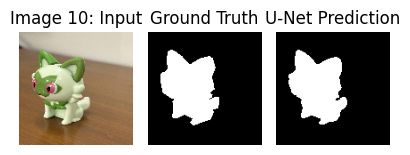

In [33]:
# Select the best performing model from Cell 5
# Typically, 1e-3 provides the most stable convergence for U-Net
best_lr = 1e-3
best_model = trained_models[best_lr]
best_model.eval() # Set model to evaluation mode

# We iterate through the entire dataset (10 images)
with torch.no_grad(): # Disable gradient calculation for faster inference
    for i in range(len(full_dataset)):
        # Retrieve the image and the ground truth mask
        image_tensor, true_mask = full_dataset[i]
        
        # Prepare the image for the model (add batch dimension and move to device)
        input_tensor = image_tensor.unsqueeze(0).to(device)
        
        # Get the prediction from the U-Net
        prediction = best_model(input_tensor)
        
        # Move back to CPU and remove batch/channel dimensions for plotting
        pred_mask = prediction.cpu().squeeze().numpy()
        
        # Apply a threshold to convert probabilities to a binary mask
        # Mathematical thresholding: mask_binary = 1 if p > 0.5 else 0
        binary_pred = (pred_mask > 0.5).astype(np.uint8)

        # Plotting the results: Input, Ground Truth, and Prediction
        fig, axes = plt.subplots(1, 3, figsize=(4, 2))
        
        # 1. Original Image (permute back to H, W, C for matplotlib)
        axes[0].imshow(image_tensor.permute(1, 2, 0).numpy())
        axes[0].set_title(f"Image {i+1}: Input")
        axes[0].axis('off')
        
        # 2. Ground Truth Mask created from your COCO JSON
        axes[1].imshow(true_mask.squeeze().numpy(), cmap='gray')
        axes[1].set_title("Ground Truth")
        axes[1].axis('off')
        
        # 3. Model's Predicted Mask
        axes[2].imshow(binary_pred, cmap='gray')
        axes[2].set_title("U-Net Prediction")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()